In [1]:
import os

from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults 
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, END
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode

load_dotenv()

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

search_tool = TavilySearchResults(max_results=2)
tools = [search_tool]

llm = ChatOpenAI(
    model="openai/gpt-5.6-luna-pro",
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    max_tokens=500
)
llm_with_tools = llm.bind_tools(tools=tools)

def model(state: AgentState):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])], 
    }

def tools_router(state: AgentState):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    

tool_node = ToolNode(tools=tools)

graph = StateGraph(AgentState)

graph.add_node("model", model)
graph.add_node("tool_node", tool_node)
graph.set_entry_point("model")

graph.add_conditional_edges("model", tools_router)
graph.add_edge("tool_node", "model")

app = graph.compile()

/tmp/ipykernel_19100/1738073380.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
/tmp/ipykernel_19100/1738073380.py:16: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=2)


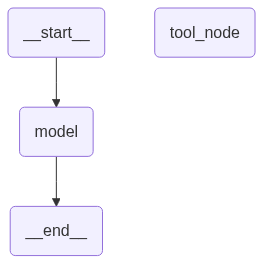

In [2]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [3]:
input = {
    "messages": ["What's the current weather in Bangalore?"]
}

events = app.stream(input=input, stream_mode="values")

for event in events: 
    print(event["messages"])

[HumanMessage(content="What's the current weather in Bangalore?", additional_kwargs={}, response_metadata={}, id='a05b9e14-4793-4b4d-92c5-575366a86fd3')]
[HumanMessage(content="What's the current weather in Bangalore?", additional_kwargs={}, response_metadata={}, id='a05b9e14-4793-4b4d-92c5-575366a86fd3'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 301, 'prompt_tokens': 1811, 'total_tokens': 2112, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0.0003617, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.0003617, 'upstream_inference_prompt_cost': 0.0001811, 'upstream_inference_completions_cost': 0.0001806}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-5.6-luna

In [5]:
input = {
    "messages": ["What's the current weather in Bangalore?"]
}

events = app.stream(input=input, stream_mode="updates")

for event in events: 
    print(event)

{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 345, 'prompt_tokens': 1805, 'total_tokens': 2150, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 236, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0.0003875, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.0003875, 'upstream_inference_prompt_cost': 0.0001805, 'upstream_inference_completions_cost': 0.000207}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-5.6-luna-pro', 'system_fingerprint': None, 'id': 'gen-1785874607-s5GujAj4n37E7CKnhTx6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fce6b-e994-7ac0-9017-52c7ff90d543-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'curre

In [6]:
input = {
    "messages": ["Hi, how are you?"]
}

events = app.astream_events(input=input, version="v2")

async for event in events: 
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, how are you?']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019fce6d-5714-7b23-ba7e-834d957aa2ff', 'metadata': {'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='5261ed70-14dd-4d1c-9b8f-c5cb291dc33b')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': '019fce6d-5718-7511-82fe-84087c15422b', 'metadata': {'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:863e73da-ac38-0dd4-cad1-3d537283157a'}, 'parent_ids': ['019fce6d-5714-7b23-ba7e-834d957aa2ff']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='5261ed70-14dd-4d1c-

In [7]:
input = {
    "messages": ["Hi, how are you?"]
}

events = app.astream_events(input=input, version="v2")

async for event in events: 
    if event["event"] == "on_chat_model_stream":
        print(event["data"]["chunk"].content, end="", flush=True)

Hi! I’m doing well, thanks for asking. How are you?